# Online Retail Business Analysis with Python

## 1. Project Overview
This project analyzes an online retail transaction dataset to uncover insights about sales performance, product demand, and customer behavior.

The analysis includes:
- Data cleaning and feature engineering
- Revenue analysis by country and product
- Monthly sales trend analysis
- Customer analysis using RFM segmentation

The goal is to identify key business patterns and provide data-driven recommendations for improving revenue, customer retention, and product strategy.

## 2. Import Libraries

In [105]:
import pandas as pd
import matplotlib.pyplot as plt

In [106]:
import seaborn as sns
sns.set_style("whitegrid")

## 3. Load Dataset

In [107]:
df = pd.read_csv("online_retail_II.csv", encoding="ISO-8859-1")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 4. Data Understanding

In [108]:
# Check the number of rows and columns
df.shape

(1067371, 8)

In [109]:
# Display column names
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [110]:
# Review data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [111]:
# Check missing values in each column
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [112]:
df["Customer ID"].nunique()

5942

In [113]:
df["StockCode"].nunique()

5305

## 5. Data Cleaning

In [114]:
# Create a working copy for cleaning and analysis
df_clean = df.copy()

In [115]:
# Convert InvoiceDate to datetime format
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

## 6. Feature Engineering

In [116]:
# Create a sales column
df["Sales"] = df["Quantity"] * df["Price"]

In [117]:
# Create sales and time-based features
df_clean["Sales"] = df_clean["Quantity"] * df_clean["Price"]
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

df_clean[["InvoiceDate", "Sales", "Year", "Month", "YearMonth"]].head()

,InvoiceDate,Sales,Year,Month,YearMonth
0,2009-12-01 07:45:00,83.4,2009,12,2009-12
1,2009-12-01 07:45:00,81.0,2009,12,2009-12
2,2009-12-01 07:45:00,81.0,2009,12,2009-12
3,2009-12-01 07:45:00,100.8,2009,12,2009-12
4,2009-12-01 07:45:00,30.0,2009,12,2009-12


## 7. Create Valid Sales Dataset

Filter transactions to include only completed sales and exclude returns or cancelled orders.

In [118]:
sales_df = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0) &
    (~df_clean["Invoice"].astype(str).str.strip().str.startswith("C"))
].copy()

sales_df.shape

(1041670, 12)

## 8. Revenue Comparison Before and After Filtering

In [119]:
# Compare revenue before and after filtering
total_revenue_raw = df_clean["Sales"].sum()
total_revenue_valid = sales_df["Sales"].sum()

print(f"Revenue from all transactions: ${total_revenue_raw:,.2f}")
print(f"Revenue from valid sales only: ${total_revenue_valid:,.2f}")

Revenue from all transactions: $19,287,250.57
Revenue from valid sales only: $20,972,594.57


## 9. Sales Analysis by Country

In [120]:
# Calculate revenue by country using valid sales only
country_sales = sales_df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    1.787098e+07
EIRE              6.644318e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.569446e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.010113e+05
Sweden            9.190372e+04
Denmark           6.986219e+04
Name: Sales, dtype: float64

## 10. Sales Analysis by Product

In [121]:
# Calculate revenue by product using valid sales only
top_products = (
    sales_df.dropna(subset=["Description"])
    .groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_products.shape

(5399,)

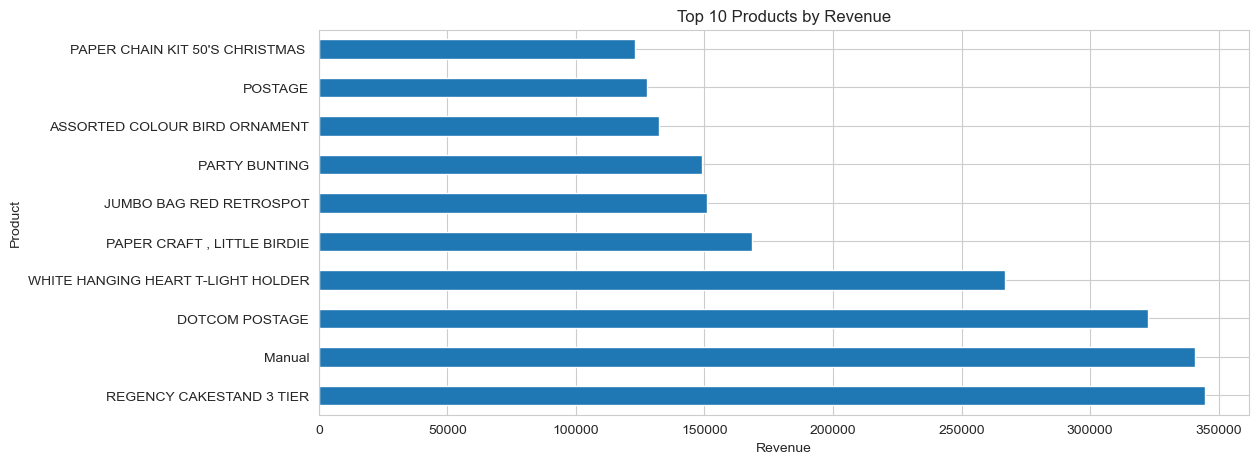

In [122]:
# Plot top 10 products by revenue
top_products.head(10).plot(kind="barh", figsize=(12,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

## 11. Monthly Revenue Trend

In [123]:
# Calculate monthly revenue
monthly_sales = sales_df.groupby("YearMonth")["Sales"].sum().sort_index()

monthly_sales

YearMonth
2009-12     825685.760
2010-01     652708.502
2010-02     553339.736
2010-03     833570.131
2010-04     681528.992
2010-05     659858.860
2010-06     752270.140
2010-07     650712.940
2010-08     697274.910
2010-09     924333.011
2010-10    1165483.910
2010-11    1470272.482
2010-12    1262598.790
2011-01     691364.560
2011-02     523631.890
2011-03     717639.360
2011-04     537808.621
2011-05     770536.020
2011-06     761739.900
2011-07     719221.191
2011-08     759138.380
2011-09    1058590.172
2011-10    1154979.300
2011-11    1509496.330
2011-12     638810.680
Freq: M, Name: Sales, dtype: float64

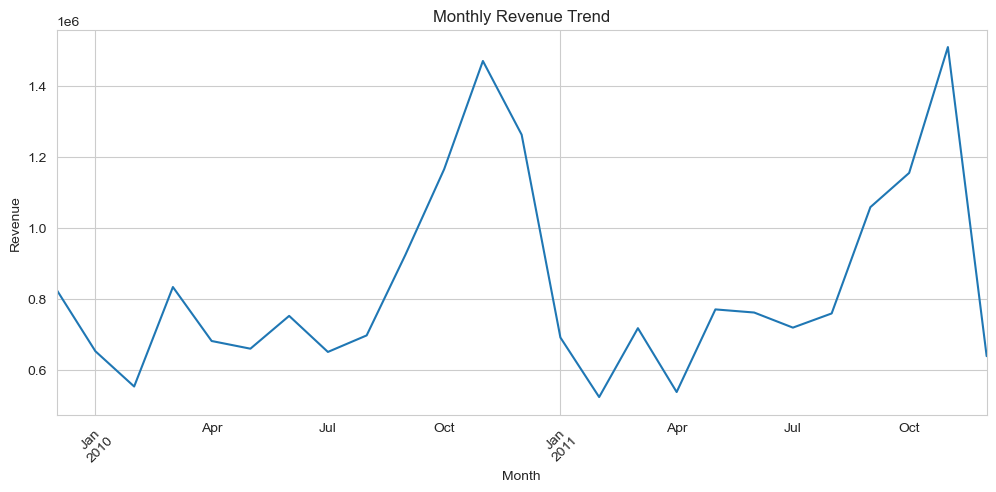

In [124]:
# Plot monthly revenue trend
monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

## 12. Top Products by Quantity vs Revenue

Compare the products that sell the most units with the products that generate the most revenue.

In [125]:
# Calculate top products by quantity sold
top_products_quantity = sales_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

top_products_quantity.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     110138
WHITE HANGING HEART T-LIGHT HOLDER     96683
ASSORTED COLOUR BIRD ORNAMENT          81809
PAPER CRAFT , LITTLE BIRDIE            80995
JUMBO BAG RED RETROSPOT                79279
MEDIUM CERAMIC TOP STORAGE JAR         78033
BROCADE RING PURSE                     71430
PACK OF 60 PINK PAISLEY CAKE CASES     56794
60 TEATIME FAIRY CAKE CASES            54716
SMALL POPCORN HOLDER                   49948
Name: Quantity, dtype: int64

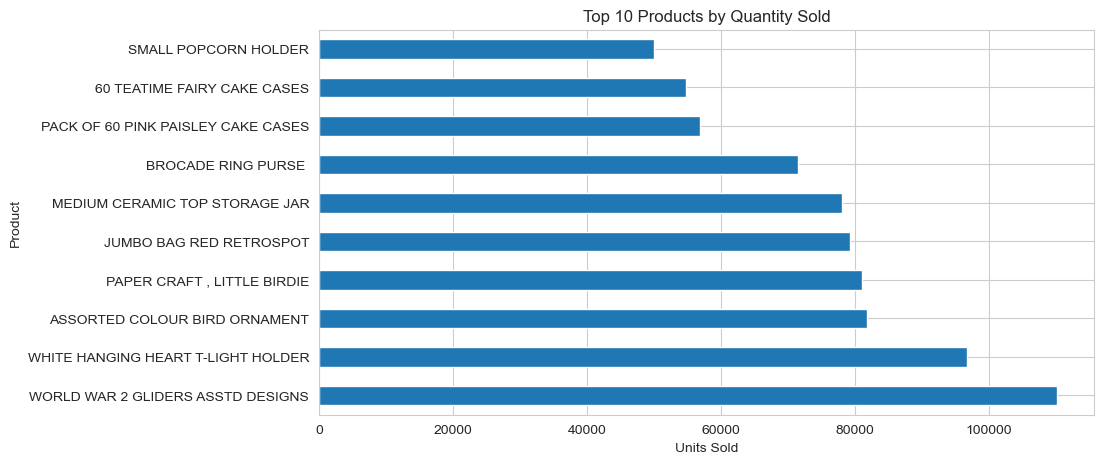

In [126]:
# Plot top 10 products by quantity sold
top_products_quantity.head(10).plot(kind="barh", figsize=(10,5))

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.show()

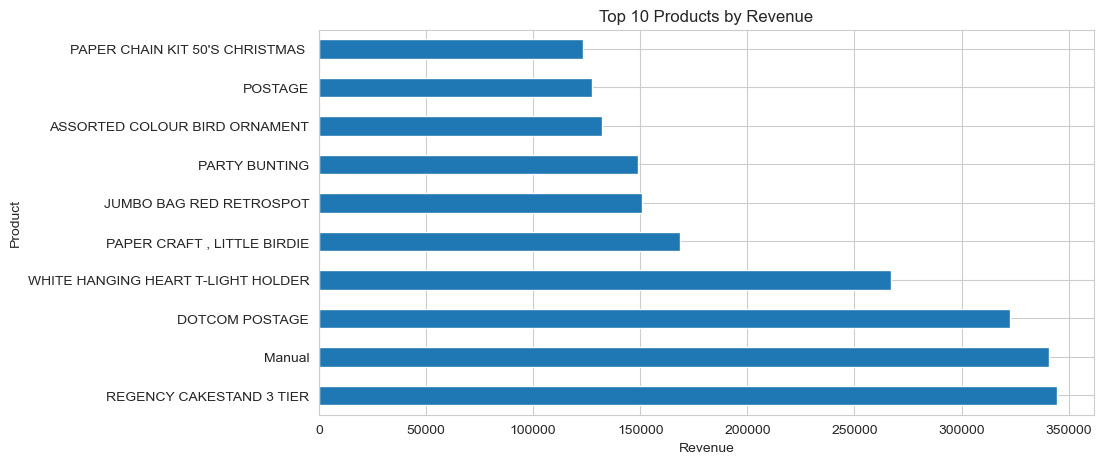

In [127]:
# Plot top 10 products by revenue
top_products.head(10).plot(kind="barh", figsize=(10,5))

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

The comparison between quantity sold and revenue shows that the most frequently purchased products are not always the highest revenue generators. This suggests that some products drive volume through low price and high demand, while others contribute more strongly to revenue due to higher unit value.

## 13. Customer Revenue Analysis

In [128]:
# Create a customer-level dataset using transactions with customer IDs
customer_df = sales_df.dropna(subset=["Customer ID"]).copy()

customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,2009-12


In [129]:
# Count unique customers
customer_df["Customer ID"].nunique()

5878

In [130]:
# Calculate top customers by revenue
top_customers = customer_df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)

top_customers.head(10)

Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Sales, dtype: float64

In [131]:
# Create a customer-level dataset using transactions with customer IDs
customer_df = sales_df.dropna(subset=["Customer ID"]).copy()

customer_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,2009-12


In [132]:
# Count unique customers
customer_df["Customer ID"].nunique()

5878

In [133]:
# Calculate top customers by revenue
top_customers = customer_df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False)

top_customers.head(10)

Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Sales, dtype: float64

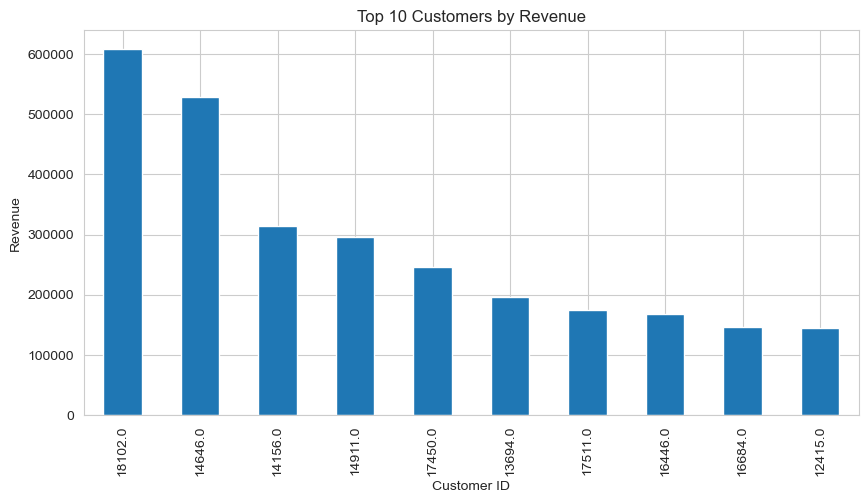

In [134]:
# Plot top 10 customers by revenue
top_customers.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.show()

## 14. RFM Analysis

In [135]:
# Create a snapshot date for recency analysis
snapshot_date = customer_df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [136]:
# Calculate RFM metrics for each customer
rfm = customer_df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


## 15. RFM Summary Statistics

In [137]:
# Review summary statistics for RFM metrics
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [138]:
# Calculate the 99th percentile of customer monetary value
monetary_cap = rfm["Monetary"].quantile(0.99)

monetary_cap
print(f"{monetary_cap:,.2f}")

29,730.42


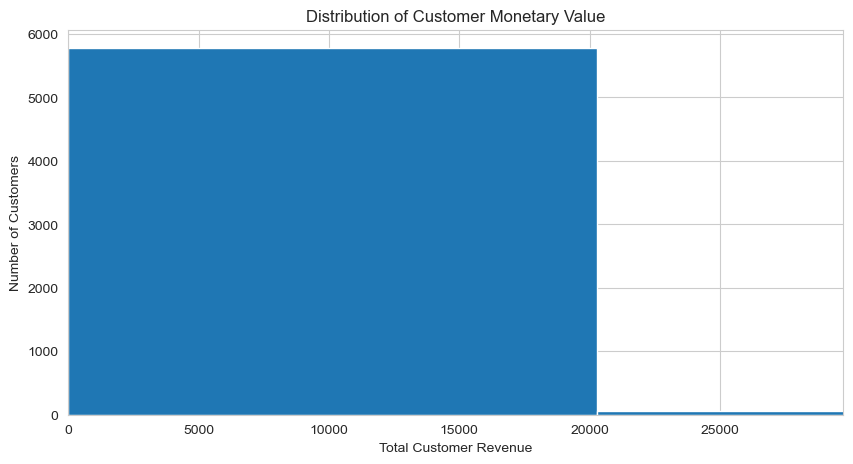

In [139]:
# Plot customer monetary value capped at the 99th percentile
rfm["Monetary"].plot(kind="hist", figsize=(10,5), bins=30)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Customer Revenue")
plt.ylabel("Number of Customers")
plt.xlim(0, monetary_cap)

plt.show()

## 16. Monetary Value Segmentation

In [140]:
# Create customer value segments based on monetary quartiles
rfm["ValueSegment"] = pd.qcut(
    rfm["Monetary"],
    q=4,
    labels=["Low Value", "Mid Value", "High Value", "Top Value"]
)

rfm.head()

,Recency,Frequency,Monetary,ValueSegment
Customer ID,,,,
12346.0,326,12,77556.46,Top Value
12347.0,2,8,5633.32,Top Value
12348.0,75,5,2019.40,High Value
12349.0,19,4,4428.69,Top Value
12350.0,310,1,334.40,Low Value


In [141]:
# Count customers in each value segment
rfm["ValueSegment"].value_counts()

ValueSegment
Low Value     1470
Top Value     1470
Mid Value     1469
High Value    1469
Name: count, dtype: int64

In [142]:
# Calculate total revenue by value segment
segment_revenue = rfm.groupby("ValueSegment", observed=False)["Monetary"].sum().sort_values(ascending=False)

segment_revenue
for segment, revenue in segment_revenue.items():
    print(f"{segment}: ${revenue:,.2f}")

Top Value: $14,480,128.36
High Value: $2,123,550.96
Mid Value: $852,549.45
Low Value: $287,200.40


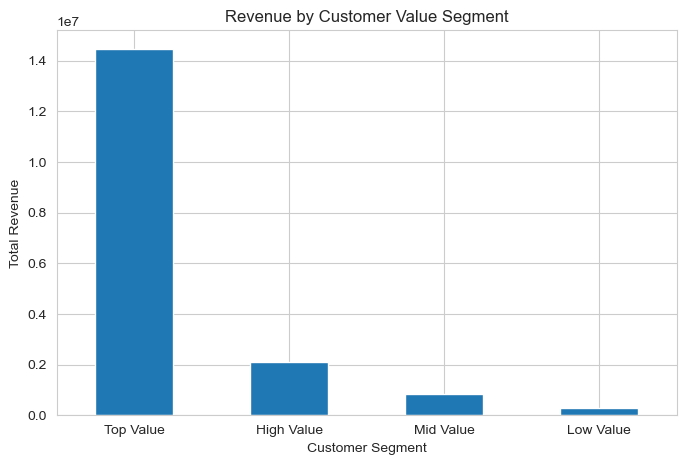

In [143]:
# Plot revenue by customer value segment
segment_revenue.plot(kind="bar", figsize=(8,5))

plt.title("Revenue by Customer Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.show()

## 17. Recency and Frequency Distributions

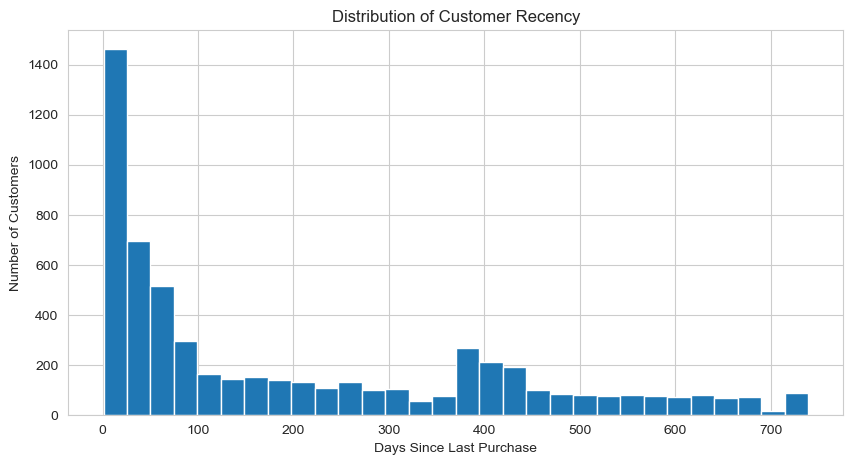

In [144]:
# Plot the distribution of customer recency
rfm["Recency"].plot(kind="hist", figsize=(10,5), bins=30)

plt.title("Distribution of Customer Recency")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.show()

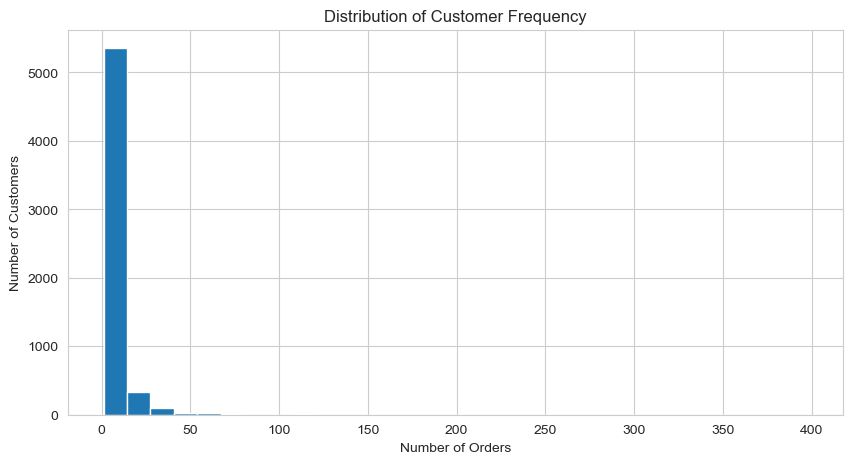

In [145]:
# Plot the distribution of customer frequency
rfm["Frequency"].plot(kind="hist", figsize=(10,5), bins=30)

plt.title("Distribution of Customer Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

## 18. RFM Scoring and Customer Segments

In [146]:
# Create RFM scores using quartiles
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1])
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Monetary"], q=4, labels=[1, 2, 3, 4])

rfm.head()

,Recency,Frequency,Monetary,ValueSegment,R_Score,F_Score,M_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,Top Value,2,4,4
12347.0,2,8,5633.32,Top Value,4,4,4
12348.0,75,5,2019.40,High Value,3,3,3
12349.0,19,4,4428.69,Top Value,4,3,4
12350.0,310,1,334.40,Low Value,2,1,1


In [147]:
# Combine RFM scores into a single segment code
rfm["RFM_Segment"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,ValueSegment,R_Score,F_Score,M_Score,RFM_Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,Top Value,2,4,4,244
12347.0,2,8,5633.32,Top Value,4,4,4,444
12348.0,75,5,2019.40,High Value,3,3,3,333
12349.0,19,4,4428.69,Top Value,4,3,4,434
12350.0,310,1,334.40,Low Value,2,1,1,211


In [148]:
# Create simple customer segment labels
rfm["CustomerSegment"] = "Other"
rfm.loc[(rfm["R_Score"] == 4) & (rfm["F_Score"] == 4) & (rfm["M_Score"] == 4), "CustomerSegment"] = "Champions"
rfm.loc[(rfm["R_Score"] >= 3) & (rfm["F_Score"] >= 3), "CustomerSegment"] = "Loyal Customers"
rfm.loc[(rfm["R_Score"] <= 2) & (rfm["F_Score"] >= 3), "CustomerSegment"] = "At Risk"
rfm.loc[(rfm["R_Score"] == 1) & (rfm["F_Score"] <= 2), "CustomerSegment"] = "Inactive"

rfm.head()

,Recency,Frequency,Monetary,ValueSegment,R_Score,F_Score,M_Score,RFM_Segment,CustomerSegment
Customer ID,,,,,,,,,
12346.0,326,12,77556.46,Top Value,2,4,4,244,At Risk
12347.0,2,8,5633.32,Top Value,4,4,4,444,At Risk
12348.0,75,5,2019.40,High Value,3,3,3,333,At Risk
12349.0,19,4,4428.69,Top Value,4,3,4,434,At Risk
12350.0,310,1,334.40,Low Value,2,1,1,211,Other


In [149]:
# Count customers by segment
rfm["CustomerSegment"].value_counts()

CustomerSegment
At Risk            2713
Other              1706
Inactive           1233
Loyal Customers     226
Name: count, dtype: int64

In [150]:
# Calculate revenue by customer segment
segment_summary = rfm.groupby("CustomerSegment", observed=False)["Monetary"].sum().sort_values(ascending=False)

segment_summary
for segment, revenue in segment_summary.items():
    print(f"{segment}: ${revenue:,.2f}")

At Risk: $15,383,731.81
Other: $1,313,191.68
Inactive: $592,090.65
Loyal Customers: $454,415.03


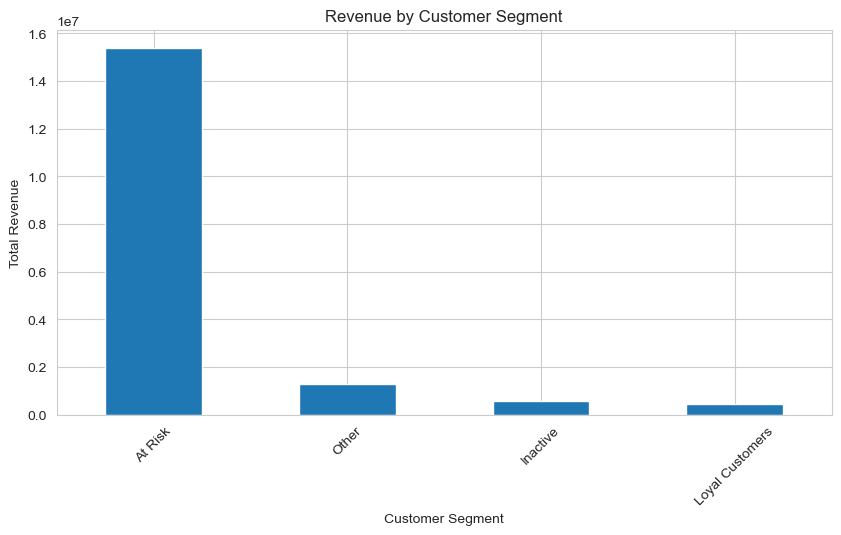

In [151]:
# Plot revenue by customer segment
segment_summary.plot(kind="bar", figsize=(10,5))

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

## 19. Pareto Revenue Analysis

In [152]:
# Prepare customer revenue data for Pareto analysis
pareto_df = rfm[["Monetary"]].sort_values("Monetary", ascending=False).reset_index()

# Calculate cumulative customer percentage and cumulative revenue percentage
pareto_df["CumulativeRevenue"] = pareto_df["Monetary"].cumsum()
pareto_df["RevenuePercent"] = pareto_df["CumulativeRevenue"] / pareto_df["Monetary"].sum() * 100
pareto_df["CustomerPercent"] = (pareto_df.index + 1) / len(pareto_df) * 100

pareto_df.head()

,Customer ID,Monetary,CumulativeRevenue,RevenuePercent,CustomerPercent
0,18102.0,608821.65,608821.65,3.431251,0.017013
1,14646.0,528602.52,1137424.17,6.410397,0.034025
2,14156.0,313946.37,1451370.54,8.179763,0.051038
3,14911.0,295972.63,1747343.17,9.847832,0.068050
4,17450.0,246973.09,1994316.26,11.239745,0.085063


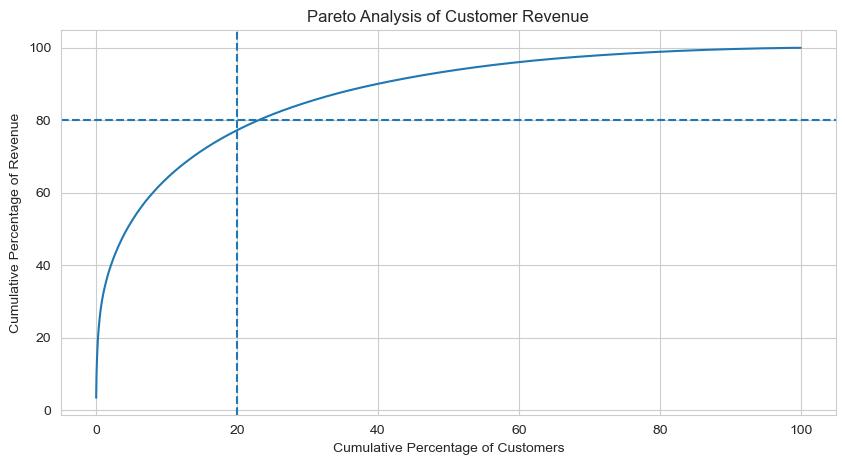

In [155]:
# Plot Pareto curve for customer revenue
plt.figure(figsize=(10,5))
plt.plot(pareto_df["CustomerPercent"], pareto_df["RevenuePercent"])

plt.axvline(20, linestyle="--")
plt.axhline(80, linestyle="--")

plt.title("Pareto Analysis of Customer Revenue")
plt.xlabel("Cumulative Percentage of Customers")
plt.ylabel("Cumulative Percentage of Revenue")

plt.grid(True)

plt.show()

The Pareto curve shows that a relatively small percentage of customers generates a large share of total revenue. 
This reinforces the importance of retaining high-value customers and closely monitoring customer concentration.

In [161]:
# Calculate customer share needed to reach key revenue thresholds
thresholds = [50, 70, 80, 90]

pareto_summary = pd.DataFrame({
    "Revenue Threshold (%)": thresholds,
    "Customer Share Needed (%)": [
        pareto_df.loc[pareto_df["RevenuePercent"] >= threshold, "CustomerPercent"].iloc[0]
        for threshold in thresholds
    ]
})

pareto_summary["Customer Share Needed (%)"] = pareto_summary["Customer Share Needed (%)"].round(2)

pareto_summary

,Revenue Threshold (%),Customer Share Needed (%)
0,50,4.41
1,70,13.81
2,80,23.02
3,90,39.84


## 20. Key Business Findings

### Sales Trends
Monthly revenue shows clear seasonality, with strong spikes toward the end of the year. This pattern suggests that holiday shopping significantly drives annual sales performance.

### Product Performance
Product analysis shows that the items generating the highest revenue are not always the same as those selling the most units. This highlights the difference between volume-driven products and high-value products.

### Customer Value Distribution
Customer spending is highly concentrated, with a small portion of customers contributing a disproportionately large share of total revenue. Pareto analysis shows that approximately 23% of customers generate 80% of revenue, while only 4.41% generate 50%.

### Customer Segmentation (RFM)
RFM analysis reveals that the largest segment of customers is classified as **At Risk**, and this group also contributes the majority of customer revenue. This indicates that many historically valuable customers have not purchased recently and may require re-engagement.

## 21. Business Recommendations

### Customer Retention Strategy
Since a relatively small share of customers drives most revenue, the company should prioritize retention campaigns for high-value customers, especially those currently classified as At Risk.

### Loyalty and Relationship Management
The business should develop stronger engagement strategies for top customers, such as loyalty rewards, personalized promotions, and proactive re-engagement efforts.

### Product Strategy
Products with high sales volume but lower revenue may serve as traffic-driving items, while high-revenue products should be prioritized in pricing, promotion, and inventory planning.

### Seasonal Planning
Given the strong year-end sales spikes, the company should align inventory, staffing, and marketing campaigns with peak seasonal demand periods.

### Customer Concentration Monitoring
Because revenue is highly concentrated among a relatively small portion of customers, the company should regularly monitor customer concentration risk and track whether key high-value customers are becoming inactive.